Imports and Data Loading

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

csv_path = '../results/hybrid_benchmark_results.csv'
df = pd.read_csv(csv_path)

display(df.head())

,M,ef_construction,batch_size,candidates_per_query,beam_search_ef,build_time_sec,throughput_vec_sec,recall_1,recall_10
0,16,100,1000,3000,1,66.1060,15127.2,0.9322,0.910150
1,16,100,1000,3000,10,59.3467,16850.1,0.9837,0.967879
2,16,100,1000,3000,30,64.4715,15510.7,0.6990,0.692057
3,16,100,10000,3000,1,59.9745,16673.8,0.9200,0.892438
4,16,100,10000,3000,10,53.9148,18547.8,0.9764,0.955605


Pareto Frontier

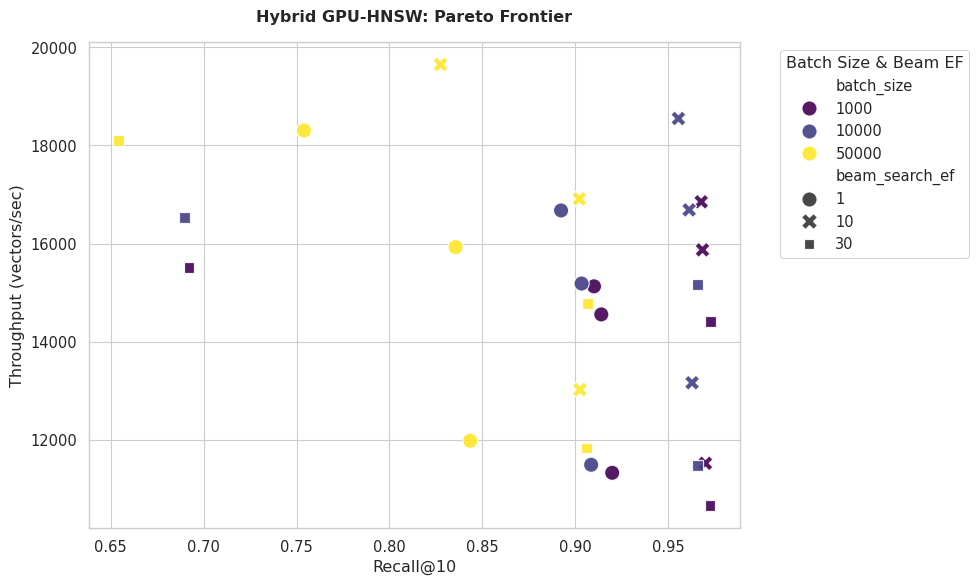

In [5]:
plt.figure(figsize=(10, 6))

# Plot Recall vs Throughput
sns.scatterplot(
    data=df, 
    x='recall_10', 
    y='throughput_vec_sec', 
    hue='batch_size', 
    style='beam_search_ef',
    palette='viridis',
    s=120, # Marker size
    alpha=0.9
)

plt.title('Hybrid GPU-HNSW: Pareto Frontier', weight='bold', pad=15)
plt.xlabel('Recall@10')
plt.ylabel('Throughput (vectors/sec)')

# Move legend outside the plot so it doesn't cover data
plt.legend(title='Batch Size & Beam EF', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../results/pareto_frontier.pdf', bbox_inches='tight') 
plt.show()

Beam Search Ablation Study

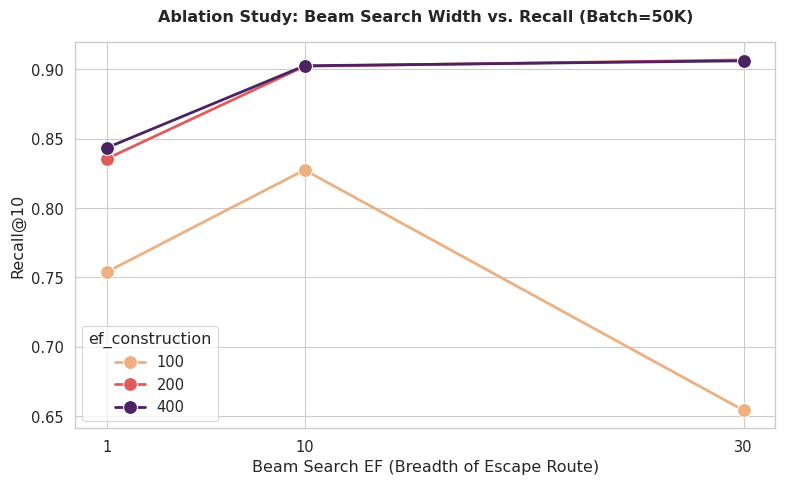

In [6]:
# Filter for the 50k batch size to isolate the beam search impact
df_50k = df[df['batch_size'] == 50000].copy()

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_50k,
    x='beam_search_ef',
    y='recall_10',
    hue='ef_construction',
    marker='o',
    palette='flare',
    linewidth=2,
    markersize=10
)

plt.title('Ablation Study: Beam Search Width vs. Recall (Batch=50K)', weight='bold', pad=15)
plt.xlabel('Beam Search EF (Breadth of Escape Route)')
plt.ylabel('Recall@10')
plt.xticks([1, 10, 30]) # Force exact x-axis ticks
plt.tight_layout()
plt.savefig('../results/ablation_beam_search.pdf', bbox_inches='tight')
plt.show()